In [1]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


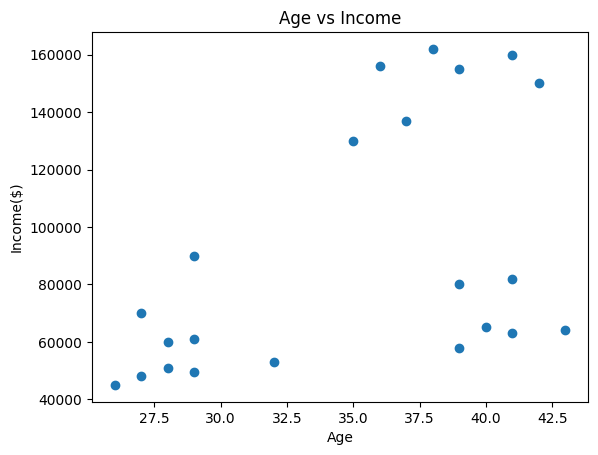

In [3]:
plt.scatter(df["Age"], df["Income($)"])
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.title("Age vs Income")
plt.show()

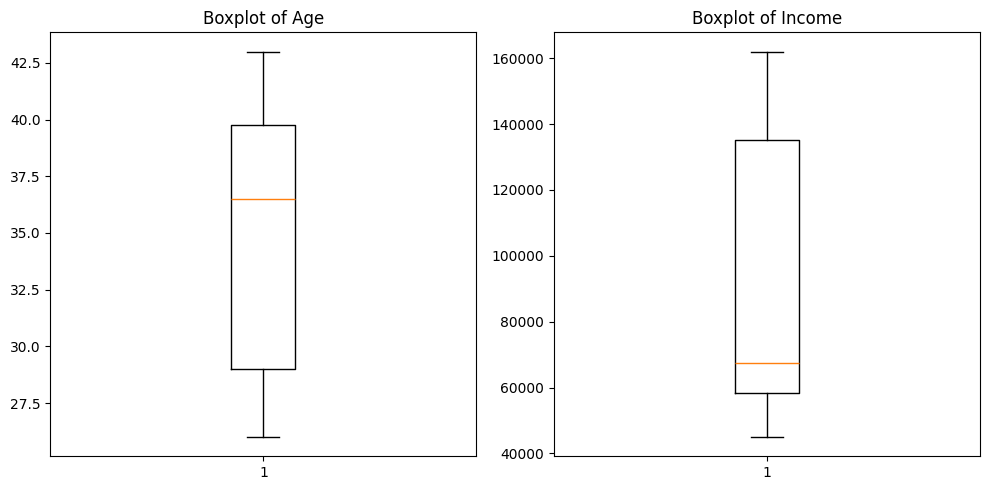

In [4]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df["Age"])
plt.title("Boxplot of Age")

plt.subplot(1, 2, 2)
plt.boxplot(df["Income($)"])
plt.title("Boxplot of Income")

plt.tight_layout()
plt.show()

In [5]:
km = KMeans(n_clusters=3)

y_predicted = km.fit_predict(df[["Age", "Income($)"]])
y_predicted

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [6]:
df['Cluster'] = y_predicted
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [7]:
km.cluster_centers_

array([[3.24166667e+01, 5.72916667e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.63333333e+01, 8.40000000e+04]])

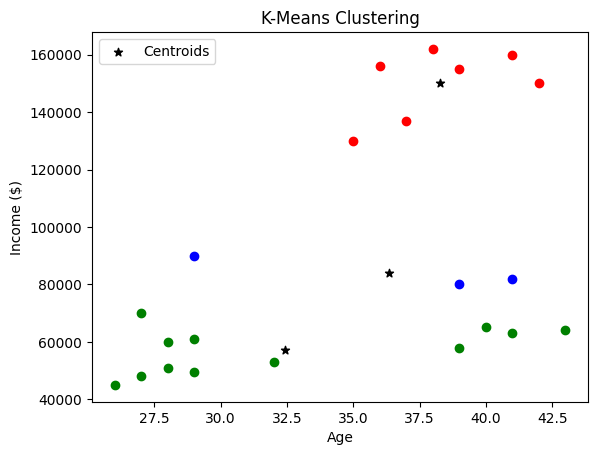

In [8]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

plt.scatter(df1.Age, df1["Income($)"], color='green')
plt.scatter(df2.Age, df2["Income($)"], color='red')
plt.scatter(df3.Age, df3["Income($)"], color='blue')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='black', marker='*', label='Centroids')
plt.xlabel("Age")
plt.ylabel("Income ($)")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [9]:
scaler = MinMaxScaler()
scaler.fit(df[["Income($)"]])
df["Income($)"] = scaler.transform(df[["Income($)"]])
scaler.fit(df[["Age"]])
df["Age"] = scaler.transform(df[["Age"]])

In [10]:
km1 = KMeans(n_clusters=3)
y_predicted1 = km1.fit_predict(df[["Age", "Income($)"]])
y_predicted1

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [11]:
km1.cluster_centers_

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

In [12]:
df['Cluster_1'] = y_predicted1
df.head()

,Name,Age,Income($),Cluster,Cluster_1
0,Rob,0.058824,0.213675,0,1
1,Michael,0.176471,0.384615,2,1
2,Mohan,0.176471,0.136752,0,1
3,Ismail,0.117647,0.128205,0,1
4,Kory,0.941176,0.897436,1,0


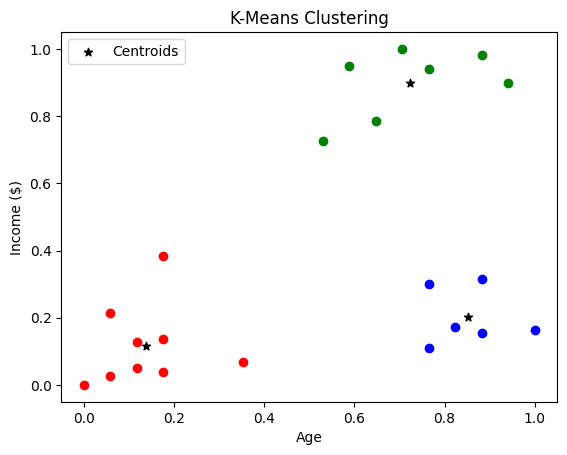

In [17]:
df1 = df[df.Cluster_1 == 0]
df2 = df[df.Cluster_1 == 1]
df3 = df[df.Cluster_1 == 2]

plt.scatter(df1.Age, df1["Income($)"], color='green')
plt.scatter(df2.Age, df2["Income($)"], color='red')
plt.scatter(df3.Age, df3["Income($)"], color='blue')

plt.scatter(km1.cluster_centers_[:, 0], km1.cluster_centers_[:, 1], color='black', marker='*', label='Centroids')
plt.xlabel("Age")
plt.ylabel("Income ($)")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [18]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[["Age", "Income($)"]])
    sse.append(km.inertia_)

In [19]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.39237665288019463,
 0.26640301246684156,
 0.21878010893330452,
 0.2246611358702123,
 0.15104831041748804,
 0.15677230507695122]

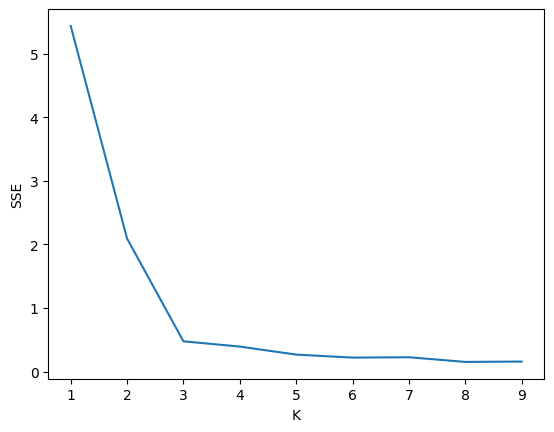

In [20]:
plt.xlabel('K')
plt.ylabel('SSE')
plt.plot(k_rng, sse)
plt.show()

# **Summary: Preparing Data for K-Means Clustering**

- 1. Why Scale?

Distance-Based: K-Means uses Euclidean Distance. Features with larger raw scales (e.g., Income) will dominate features with smaller scales (e.g., Age).
Feature Equality: Scaling ensures every feature has an equal "vote" in determining the clusters.
Convergence: Helps the algorithm find the centers faster and prevents "elongated" clusters.

- 2. Handling Extreme Values (Outliers)

The Problem: K-Means uses the Mean, which is highly sensitive to outliers. A single extreme value can pull a centroid away from the dense part of the data.
Legitimate Data: If extreme values are real (not errors), do not oversample them for clustering; this pulls centroids even further away.
Transformation: Use Log Transformation (or log1p if you have zeros) to "squash" skewed data and bring outliers closer to the mean.

- 3. Choosing the Right Scaler

Scaler	Best Used When...	Sensitivity to Outliers
StandardScaler	Data is Gaussian (Normal) and has few outliers.	High
MinMaxScaler	You need a specific range (0-1) and no outliers.	Very High
RobustScaler	Data contains significant outliers. Uses Median/IQR.	Low (Best for Outliers)

- 4. Best Practice Pipeline

Inspect: Check for skewness and outliers (Boxplots/Histograms).
Transform: Apply Log/Power Transformation if data is heavily right-skewed.
Scale: Apply RobustScaler or StandardScaler.
Cluster: Run K-Means on the transformed and scaled features.

Outliers shift centroids disproportionately

Even valid outliers can break clustering

- Consider:

Removing extreme outliers (IQR / z-score)

Using RobustScaler

Using K-Medoids or DBSCAN instead of K-Means

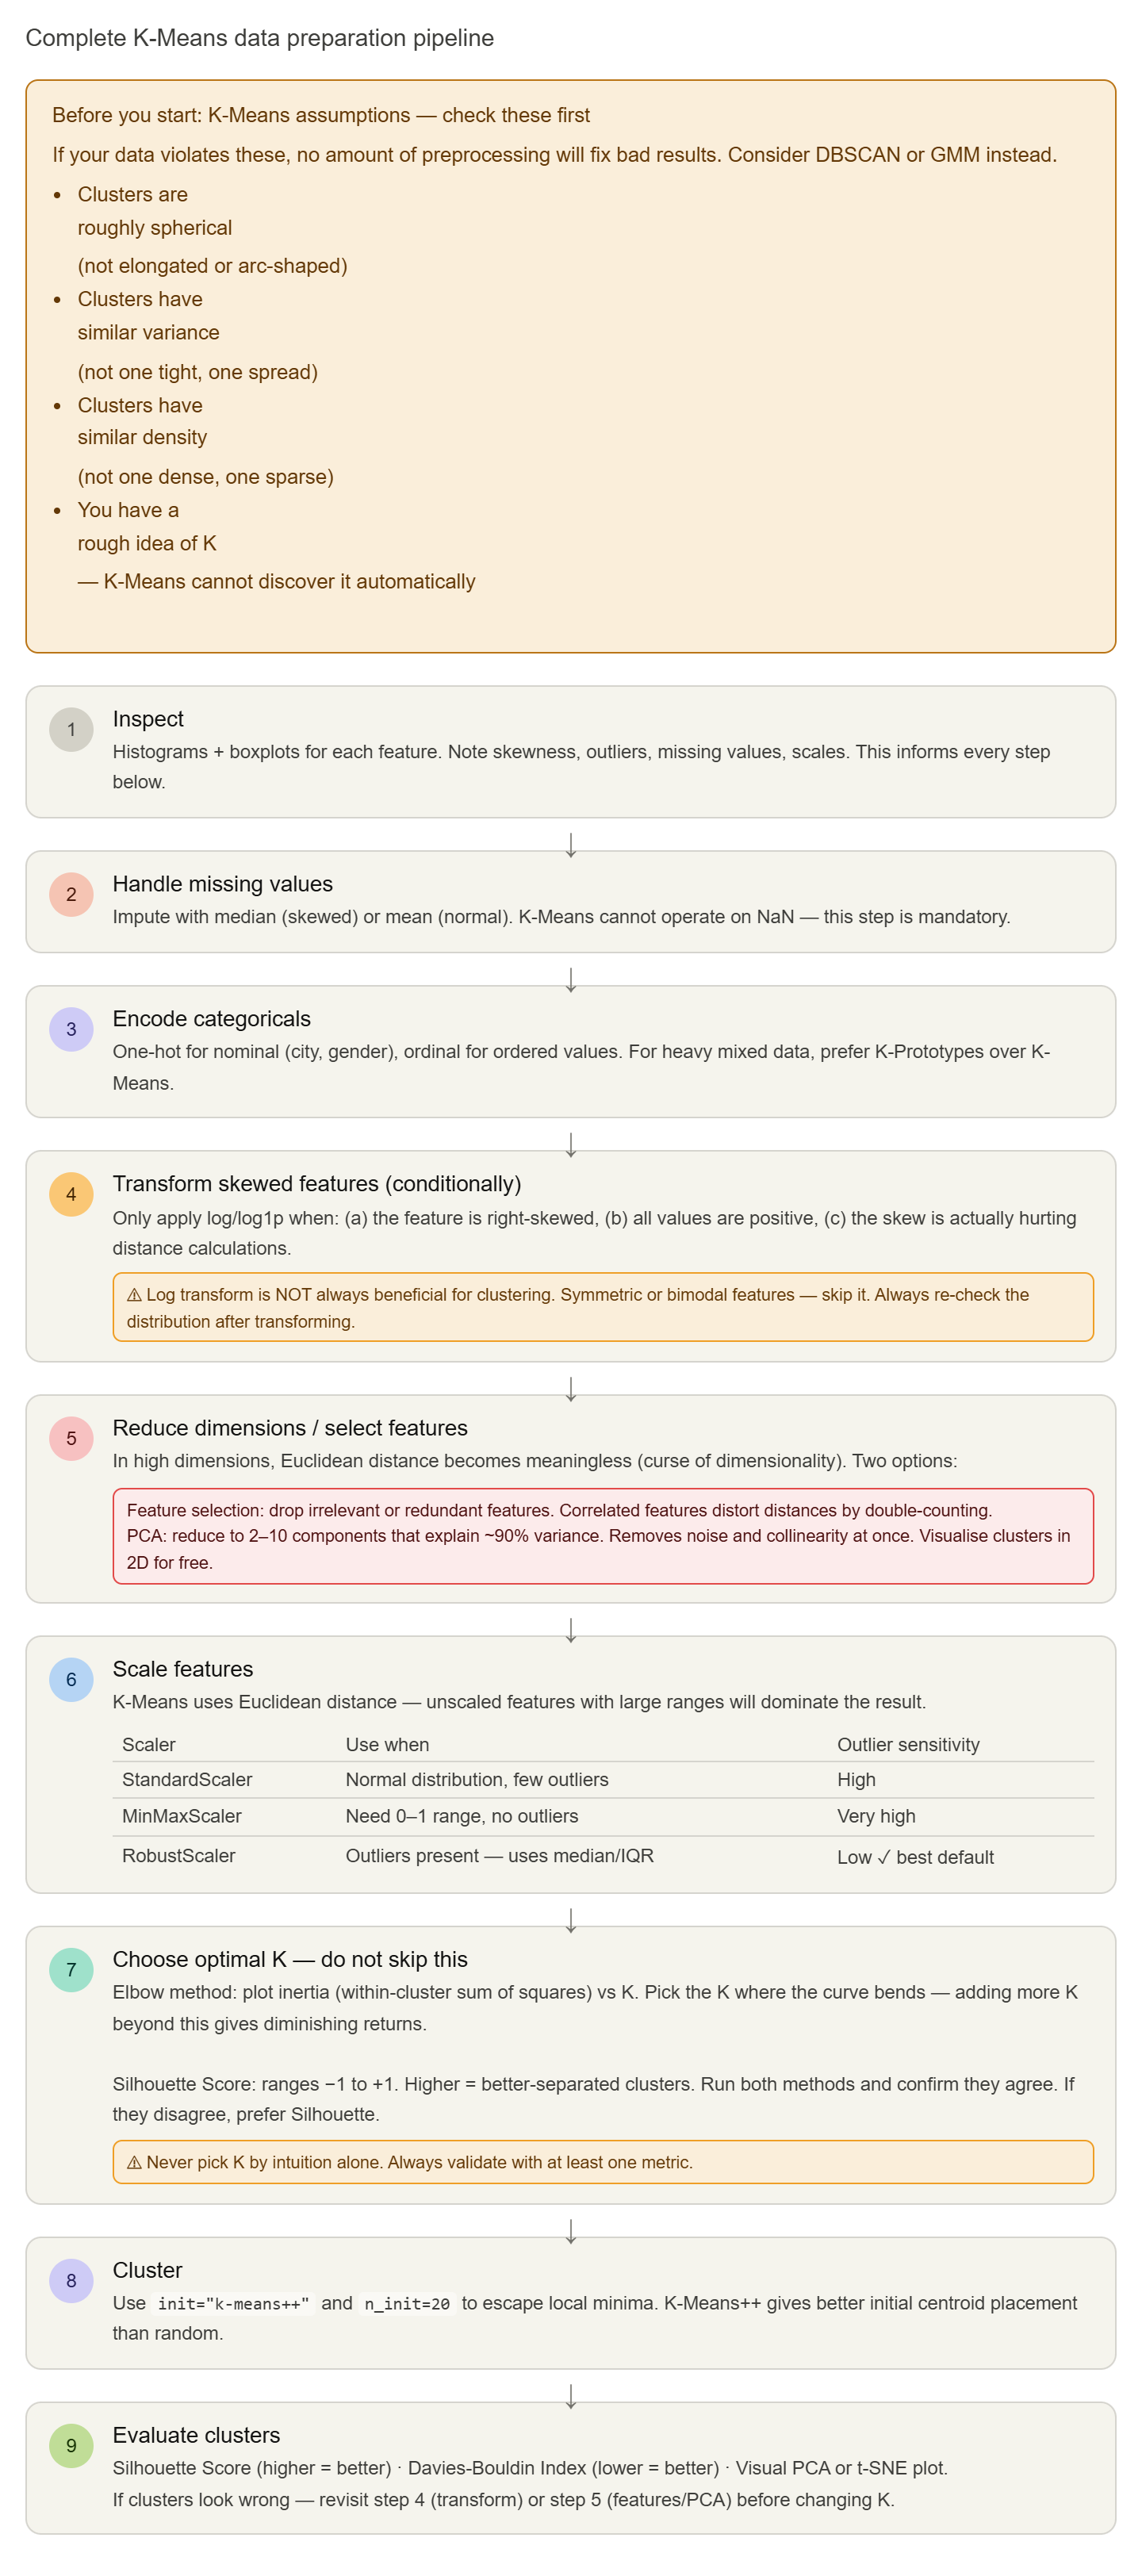

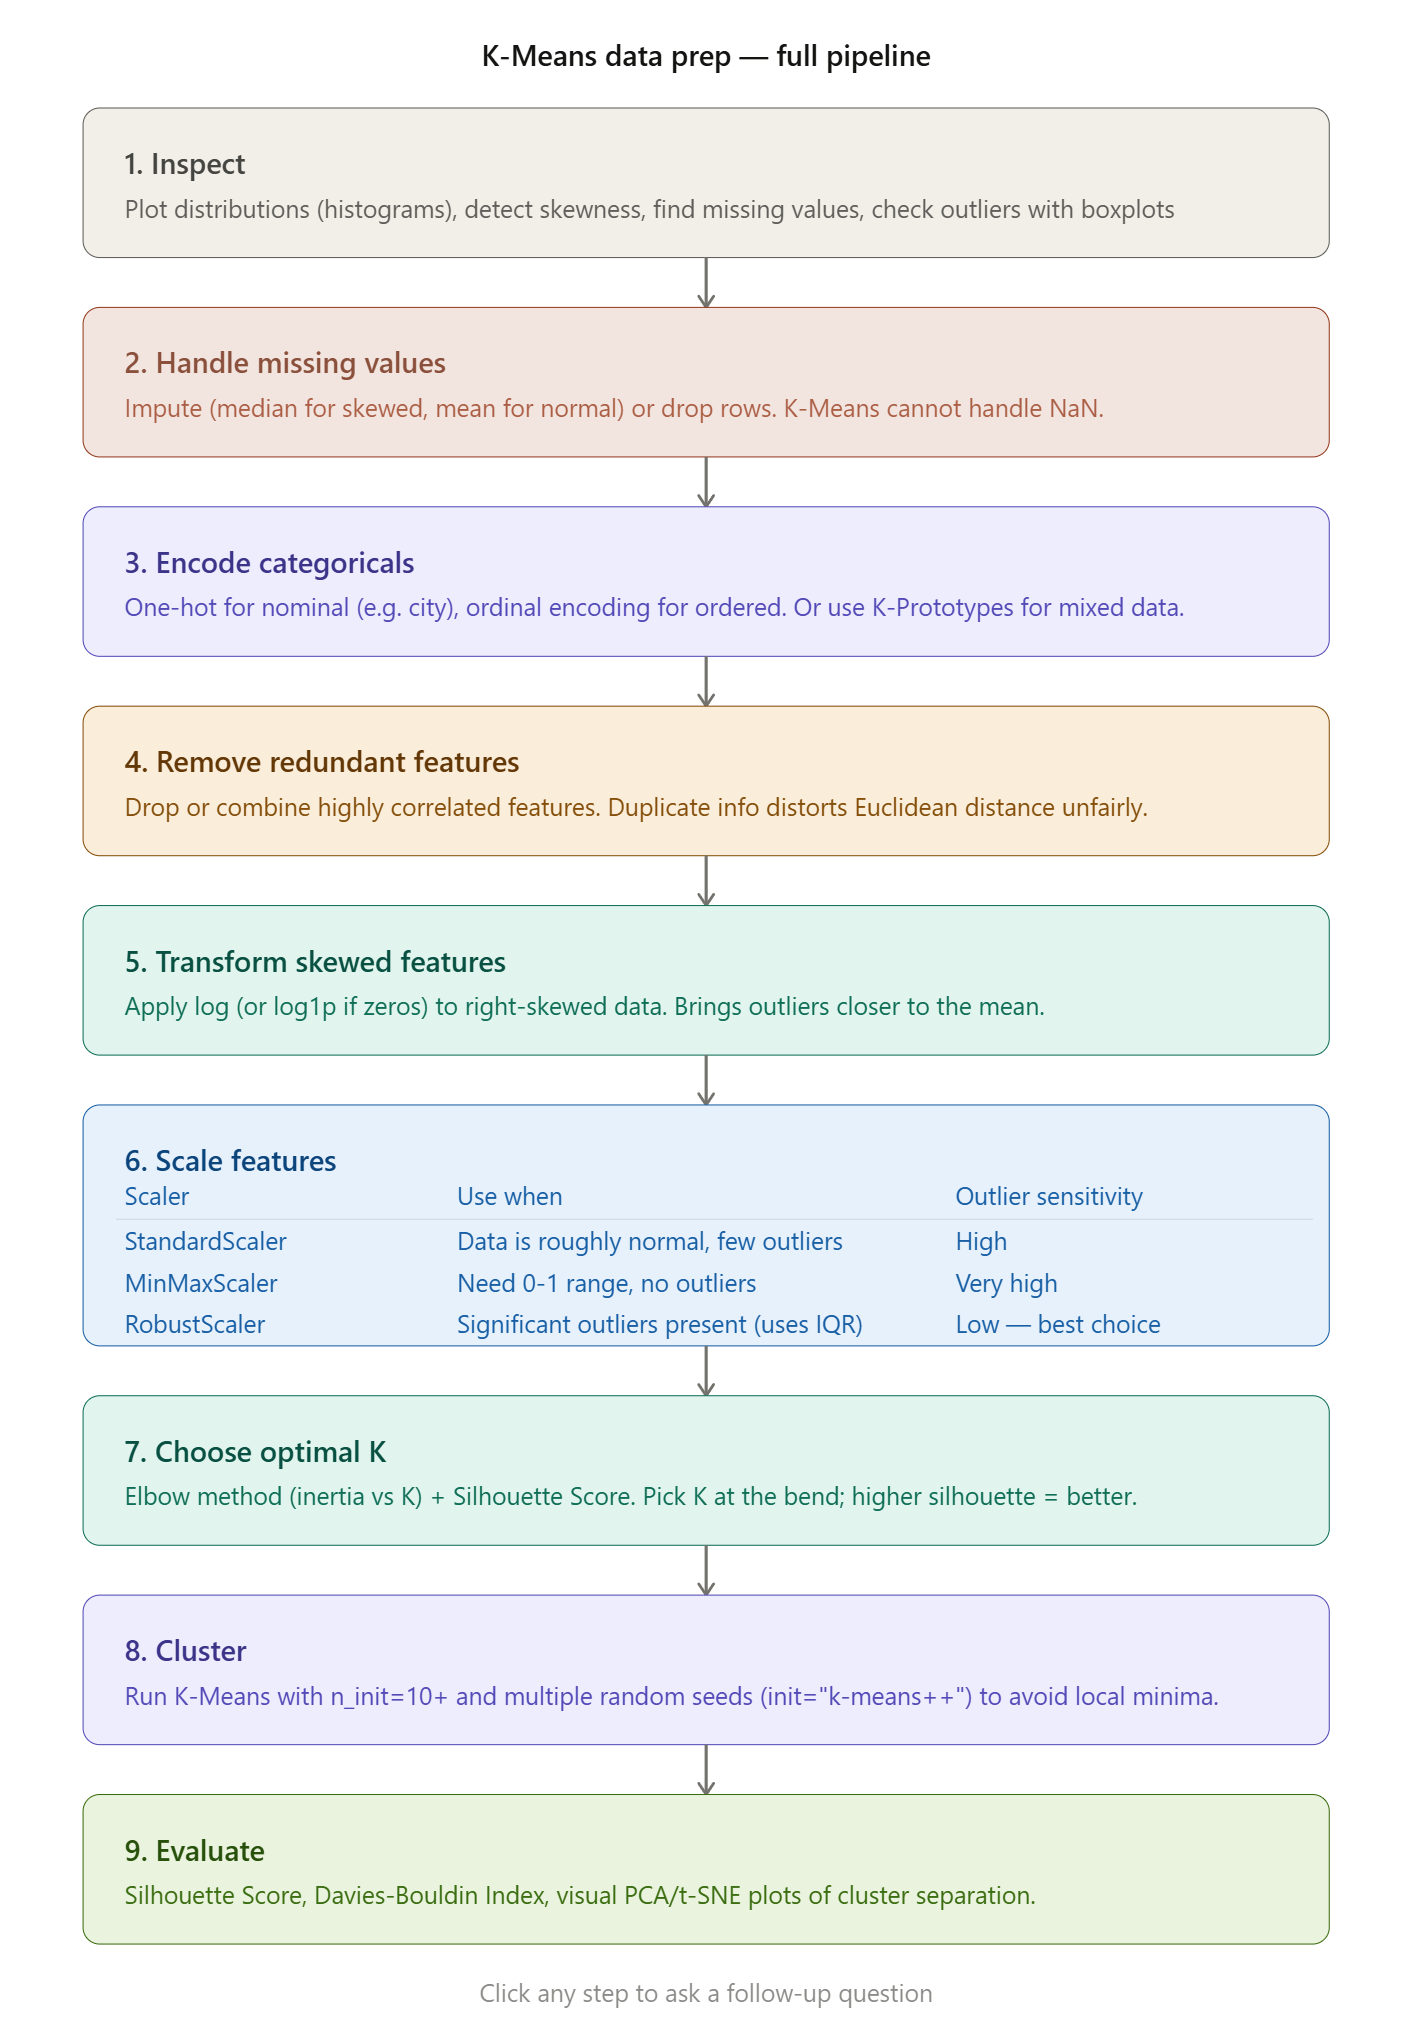

**First, I explore the data to understand distributions and detect outliers. Since K-Means is sensitive to outliers, I either remove or cap them, or switch to a robust scaling approach. If features are highly skewed, I apply log or power transformations carefully. Then I scale features using StandardScaler or RobustScaler depending on outliers. Optionally, I apply PCA to reduce dimensionality and noise. Next, I determine the optimal number of clusters using the Elbow method or Silhouette score. Finally, I train K-Means with multiple initializations and evaluate cluster quality both statistically and from a business perspective.”**

# **To make a 3D model using kmeans you will use something called POID-net to work on 3D object and i must know how the Dimensions in kmeans work**